svm kernel comparison
-----------------------------------
kernel: linear -> accuracy: 0.956
kernel: rbf -> accuracy: 0.974
kernel: poly -> accuracy: 0.868
kernel: sigmoid -> accuracy: 0.947


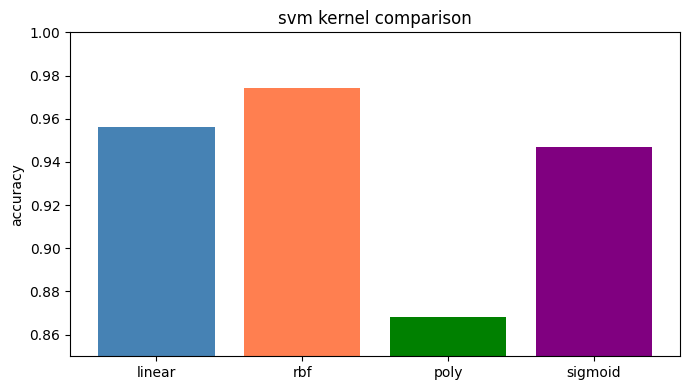

In [2]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

kernels = ["linear", "rbf", "poly", "sigmoid"]
scores = {}

print("svm kernel comparison")
print("-" * 35)

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(x_train, y_train)
    score = round(accuracy_score(y_test, model.predict(x_test)), 3)
    scores[k] = score
    print("kernel:", k, "-> accuracy:", score)

plt.figure(figsize=(7, 4))
plt.bar(scores.keys(), scores.values(),
        color=["steelblue", "coral", "green", "purple"])
plt.title("svm kernel comparison")
plt.ylabel("accuracy")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()